# Análisis exploratorio de generación eléctrica

## Estructura del archivo

https://www.eia.gov/electricity/data.php

Estructura del archivo xlsx

* hojas 0     : Encabezado en la fila 0
* hojas 1 - 15: Encabezado en la fila 5

In [46]:
import pandas as pd

RUTA = 'datos/generation_monthly.xlsx'

SKIP_ROWS = [None] * 5 + [4] * 15
SHEET_NAMES = list(range(len(SKIP_ROWS)))

DF = [None] * len(SHEET_NAMES)

for i, sheet in enumerate(SHEET_NAMES):
    DF[i] = pd.read_excel(RUTA, sheet_name=sheet, skiprows=SKIP_ROWS[i])
    print(i)

for df in DF:
    print(df.columns)

print(df.shape)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Megawatthours)'],
      dtype='str')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Megawatthours)'],
      dtype='str')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Megawatthours)'],
      dtype='str')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Megawatthours)'],
      dtype='str')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Megawatthours)'],
      dtype='str')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Megawatthours)'],
      dtype='str')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Megawatthours)'],
      dtype='str')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY 

/home/jair/anaconda3/envs/series/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [47]:
RUTA = 'datos/generation_monthly.xlsx'

SKIP_ROWS = [None] * 5 + [4] * 15
SHEET_NAMES = list(range(len(SKIP_ROWS)))

DF = [None] * len(SHEET_NAMES)
NAMES = ['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE', 'GENERATION (Mwh)']

for i, sheet in enumerate(SHEET_NAMES):
    DF[i] = pd.read_excel(RUTA, sheet_name=sheet, skiprows=SKIP_ROWS[i], names = NAMES)

for df in DF:
    print(df.columns)

Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Mwh)'],
      dtype='str')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Mwh)'],
      dtype='str')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Mwh)'],
      dtype='str')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Mwh)'],
      dtype='str')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Mwh)'],
      dtype='str')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Mwh)'],
      dtype='str')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Mwh)'],
      dtype='str')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE',
       'GENERATION (Mwh)'],
      dtype='str')
Index(['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOU

/home/jair/anaconda3/envs/series/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [48]:
df = pd.concat(DF, ignore_index=True)
df

,YEAR,MONTH,STATE,TYPE OF PRODUCER,ENERGY SOURCE,GENERATION (Mwh)
0,2001,1,AK,Total Electric Power Industry,Coal,46903.0
1,2001,1,AK,Total Electric Power Industry,Petroleum,71085.0
2,2001,1,AK,Total Electric Power Industry,Natural Gas,367521.0
3,2001,1,AK,Total Electric Power Industry,Hydroelectric Conventional,104549.0
4,2001,1,AK,Total Electric Power Industry,Wind,87.0
...,...,...,...,...,...,...
592549,2026,2,WY,"Electric Generators, Electric Utilities",Coal,1514334.0
592550,2026,2,WY,"Electric Generators, Electric Utilities",Hydroelectric Conventional,113942.0
592551,2026,2,WY,"Electric Generators, Electric Utilities",Natural Gas,225535.0
592552,2026,2,WY,"Electric Generators, Electric Utilities",Petroleum,3737.0


* Comportamiento historico de la serie a nivel de **estados**
* Comportamiento historico de la serie a nivel de **tipo de productos**
* Comportamiento historico de la serie a nivel de **fuente de energía**

> **Existen fuentes de generación que se han mantenido estables o que han incrementado/reducido su nivel de generacipon en el periodo de 2001-2004?**

$\rightarrow$ La fuente que usa carbón ha disminuido?

$\rightarrow$ La fuente de petróleo se ha mantenido constante?

$\rightarrow$ La fuente de viento ha aumentado?

## Preprocesamiento

In [49]:
df['DATE'] = pd.to_datetime(df[['YEAR', 'MONTH']].assign(DAY = 1))

df.set_index('DATE', inplace= True)
df.drop(columns = ['YEAR', 'MONTH'], inplace = True)

df

,STATE,TYPE OF PRODUCER,ENERGY SOURCE,GENERATION (Mwh)
DATE,,,,
2001-01-01,AK,Total Electric Power Industry,Coal,46903.0
2001-01-01,AK,Total Electric Power Industry,Petroleum,71085.0
2001-01-01,AK,Total Electric Power Industry,Natural Gas,367521.0
2001-01-01,AK,Total Electric Power Industry,Hydroelectric Conventional,104549.0
2001-01-01,AK,Total Electric Power Industry,Wind,87.0
...,...,...,...,...
2026-02-01,WY,"Electric Generators, Electric Utilities",Coal,1514334.0
2026-02-01,WY,"Electric Generators, Electric Utilities",Hydroelectric Conventional,113942.0
2026-02-01,WY,"Electric Generators, Electric Utilities",Natural Gas,225535.0


In [50]:
df = df.drop(columns=['STATE', 'TYPE OF PRODUCER'])
df

,ENERGY SOURCE,GENERATION (Mwh)
DATE,,
2001-01-01,Coal,46903.0
2001-01-01,Petroleum,71085.0
2001-01-01,Natural Gas,367521.0
2001-01-01,Hydroelectric Conventional,104549.0
2001-01-01,Wind,87.0
...,...,...
2026-02-01,Coal,1514334.0
2026-02-01,Hydroelectric Conventional,113942.0
2026-02-01,Natural Gas,225535.0


In [51]:
df['ENERGY SOURCE'].value_counts()

ENERGY SOURCE
Total                             86435
Natural Gas                       78356
Petroleum                         74215
Coal                              55241
Other Biomass                     54906
Hydroelectric Conventional        45844
Other                             44268
Wood and Wood Derived Fuels       36156
Wind                              31499
Solar Thermal and Photovoltaic    28157
Other Gases                       21001
Nuclear                           19437
Pumped Storage                    11952
Geothermal                         5087
Name: count, dtype: int64

Agrupar los datos por fuentes de generación

In [52]:
grupos = df.groupby(['ENERGY SOURCE', df.index]).sum()
grupos

GENERATION (Mwh)
ENERGY SOURCE               DATE                        
Coal                        2001-01-01       709148444.0
                            2001-02-01       598941934.0
                            2001-03-01       621076042.0
                            2001-04-01       562682612.0
                            2001-05-01       606371658.0
...                                                  ...
Wood and Wood Derived Fuels 2025-10-01         9868913.0
                            2025-11-01        10325175.0
                            2025-12-01        11047374.0
                            2026-01-01        11312216.0
                            2026-02-01        10244356.0

[4228 rows x 1 columns]

### Crear las series por aparte

In [53]:
nombres_series = grupos.index.get_level_values('ENERGY SOURCE').unique()
nombres_series

Index(['Coal', 'Geothermal', 'Hydroelectric Conventional', 'Natural Gas',
       'Nuclear', 'Other', 'Other Biomass', 'Other Gases', 'Petroleum',
       'Pumped Storage', 'Solar Thermal and Photovoltaic', 'Total', 'Wind',
       'Wood and Wood Derived Fuels'],
      dtype='str', name='ENERGY SOURCE')

In [54]:
series = {}
for nombre in nombres_series:
    if nombre != 'Total':
        serie = grupos.xs(nombre, level='ENERGY SOURCE').sort_index()
        series[nombre] = serie

series['Coal']

,GENERATION (Mwh)
DATE,
2001-01-01,709148444.0
2001-02-01,598941934.0
2001-03-01,621076042.0
2001-04-01,562682612.0
2001-05-01,606371658.0
...,...
2025-10-01,216075418.0
2025-11-01,217959149.0
2025-12-01,267485103.0


In [ ]:
for key, value in series.items():
    print(f'\n{key}: {len(value)}')
    print(f'Inicio: {series[key].index.min()} - {series[key].index.max()}')

# Todas tienen los mismos registros


Coal: 302
Inicio: 2001-01-01 00:00:00 - 2026-02-01 00:00:00

Geothermal: 302
Inicio: 2001-01-01 00:00:00 - 2026-02-01 00:00:00

Hydroelectric Conventional: 302
Inicio: 2001-01-01 00:00:00 - 2026-02-01 00:00:00

Natural Gas: 302
Inicio: 2001-01-01 00:00:00 - 2026-02-01 00:00:00

Nuclear: 302
Inicio: 2001-01-01 00:00:00 - 2026-02-01 00:00:00

Other: 302
Inicio: 2001-01-01 00:00:00 - 2026-02-01 00:00:00

Other Biomass: 302
Inicio: 2001-01-01 00:00:00 - 2026-02-01 00:00:00

Other Gases: 302
Inicio: 2001-01-01 00:00:00 - 2026-02-01 00:00:00

Petroleum: 302
Inicio: 2001-01-01 00:00:00 - 2026-02-01 00:00:00

Pumped Storage: 302
Inicio: 2001-01-01 00:00:00 - 2026-02-01 00:00:00

Solar Thermal and Photovoltaic: 302
Inicio: 2001-01-01 00:00:00 - 2026-02-01 00:00:00

Wind: 302
Inicio: 2001-01-01 00:00:00 - 2026-02-01 00:00:00

Wood and Wood Derived Fuels: 302
Inicio: 2001-01-01 00:00:00 - 2026-02-01 00:00:00


### Datos con registros faltantes

In [ ]:
for key, value in series.items():
    faltan = series[key].isna().sum()
    print(f'Faltantes {key}: {faltan}')

Faltantes Coal: GENERATION (Mwh)    0
dtype: int64
Faltantes Geothermal: GENERATION (Mwh)    0
dtype: int64
Faltantes Hydroelectric Conventional: GENERATION (Mwh)    0
dtype: int64
Faltantes Natural Gas: GENERATION (Mwh)    0
dtype: int64
Faltantes Nuclear: GENERATION (Mwh)    0
dtype: int64
Faltantes Other: GENERATION (Mwh)    0
dtype: int64
Faltantes Other Biomass: GENERATION (Mwh)    0
dtype: int64
Faltantes Other Gases: GENERATION (Mwh)    0
dtype: int64
Faltantes Petroleum: GENERATION (Mwh)    0
dtype: int64
Faltantes Pumped Storage: GENERATION (Mwh)    0
dtype: int64
Faltantes Solar Thermal and Photovoltaic: GENERATION (Mwh)    0
dtype: int64
Faltantes Wind: GENERATION (Mwh)    0
dtype: int64
Faltantes Wood and Wood Derived Fuels: GENERATION (Mwh)    0
dtype: int64


### Datos con registros Faltantes

In [68]:
print('Registros Faltantes')
print('*'*20)
for key, value in series.items():
    serie = series[key]

    rango_completo = pd.date_range(start = serie.index.min(), end = serie.index.max(), freq = 'MS')
    serie_reindex = serie.reindex(rango_completo)

    n_faltantes = serie_reindex.isna().sum()
    print(f'{n_faltantes}: {key}')

Registros Faltantes
********************
GENERATION (Mwh)    0
dtype: int64: Coal
GENERATION (Mwh)    0
dtype: int64: Geothermal
GENERATION (Mwh)    0
dtype: int64: Hydroelectric Conventional
GENERATION (Mwh)    0
dtype: int64: Natural Gas
GENERATION (Mwh)    0
dtype: int64: Nuclear
GENERATION (Mwh)    0
dtype: int64: Other
GENERATION (Mwh)    0
dtype: int64: Other Biomass
GENERATION (Mwh)    0
dtype: int64: Other Gases
GENERATION (Mwh)    0
dtype: int64: Petroleum
GENERATION (Mwh)    0
dtype: int64: Pumped Storage
GENERATION (Mwh)    0
dtype: int64: Solar Thermal and Photovoltaic
GENERATION (Mwh)    0
dtype: int64: Wind
GENERATION (Mwh)    0
dtype: int64: Wood and Wood Derived Fuels


### Combinarlas en un DataFrame

In [71]:
SERIES = pd.concat([series[key] for key in sorted(series)], axis=1)
SERIES.columns = list(sorted(series.keys()))
SERIES

,Coal,Geothermal,Hydroelectric Conventional,Natural Gas,Nuclear,Other,Other Biomass,Other Gases,Petroleum,Pumped Storage,Solar Thermal and Photovoltaic,Wind,Wood and Wood Derived Fuels
DATE,,,,,,,,,,,,,
2001-01-01,709148444.0,4917300.0,75408194.0,169554652.0,274828308.0,3966680.0,4834584.0,2873768.0,72447372.0,-2354504.0,26000.0,1557000.0,12764848.0
2001-02-01,598941934.0,4292176.0,69891562.0,151867704.0,245089628.0,3487797.0,4385324.0,2702636.0,41366012.0,-2827824.0,50272.0,1724968.0,10788604.0
2001-03-01,621076042.0,4760092.0,81908758.0,177457656.0,248562848.0,3724622.0,4756158.0,3076724.0,46932022.0,-3093380.0,125992.0,2128480.0,11410160.0
2001-04-01,562682612.0,4379964.0,72051976.0,183370982.0,224012104.0,3829824.0,4748957.0,2791372.0,43453506.0,-3183660.0,155036.0,2738782.0,11284028.0
2001-05-01,606371658.0,4285520.0,76702540.0,203736820.0,246049780.0,3945070.0,4842966.0,3138220.0,41559958.0,-2490104.0,324212.0,2540116.0,10959732.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,216075418.0,5068250.0,66178323.0,575939056.0,236888992.0,1988976.0,4643422.0,4342271.0,5517126.0,-2053808.0,98421834.0,158134325.0,9868913.0
2025-11-01,217959149.0,5052854.0,73658196.0,526261221.0,255237428.0,2214769.0,4751902.0,3467612.0,5258556.0,-2439904.0,74368269.0,163827198.0,10325175.0
2025-12-01,267485103.0,5421955.0,95679850.0,592109580.0,290084448.0,2244715.0,4856064.0,3201196.0,8733439.0,-1848624.0,61569518.0,188190640.0,11047374.0


In [72]:
SERIES.describe()

,Coal,Geothermal,Hydroelectric Conventional,Natural Gas,Nuclear,Other,Other Biomass,Other Gases,Petroleum,Pumped Storage,Solar Thermal and Photovoltaic,Wind,Wood and Wood Derived Fuels
count,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02,3.020000e+02
mean,4.823794e+08,5.125115e+06,8.898733e+07,3.995062e+08,2.632517e+08,4.123318e+06,5.957872e+06,4.084893e+06,1.565457e+07,-2.077862e+06,1.799899e+07,6.314438e+07,1.254282e+07
std,1.728433e+08,3.335327e+05,1.568509e+07,1.518076e+08,1.920446e+07,6.957426e+05,8.718794e+05,5.909281e+05,1.344066e+07,6.342545e+05,2.752571e+07,5.366869e+07,1.215298e+06
min,1.489835e+08,3.934126e+06,5.746968e+07,1.518677e+08,2.181894e+08,1.559614e+06,4.304091e+06,2.535551e+06,3.827944e+06,-3.991422e+06,1.085200e+04,1.557000e+06,8.959659e+06
25%,3.250546e+08,4.913232e+06,7.814272e+07,2.717076e+08,2.496479e+08,3.916606e+06,5.207025e+06,3.685918e+06,6.463773e+06,-2.548414e+06,2.798410e+05,1.056061e+07,1.172191e+07
50%,5.128498e+08,5.108236e+06,8.724477e+07,3.892152e+08,2.618120e+08,4.244021e+06,5.884095e+06,4.093974e+06,8.951591e+06,-2.016441e+06,3.306399e+06,5.453483e+07,1.259050e+07
75%,6.327248e+08,5.365738e+06,9.915511e+07,5.055857e+08,2.793805e+08,4.537246e+06,6.732551e+06,4.453291e+06,2.020283e+07,-1.636209e+06,2.643586e+07,1.027050e+08,1.336196e+07
max,7.605393e+08,5.937556e+06,1.304285e+08,8.238350e+08,2.985962e+08,5.983758e+06,7.955108e+06,5.805987e+06,7.244737e+07,-4.128840e+05,1.336964e+08,2.023659e+08,1.535084e+07


In [73]:
SERIES.drop(columns=['Pumped Storage'], inplace=True)
SERIES

,Coal,Geothermal,Hydroelectric Conventional,Natural Gas,Nuclear,Other,Other Biomass,Other Gases,Petroleum,Solar Thermal and Photovoltaic,Wind,Wood and Wood Derived Fuels
DATE,,,,,,,,,,,,
2001-01-01,709148444.0,4917300.0,75408194.0,169554652.0,274828308.0,3966680.0,4834584.0,2873768.0,72447372.0,26000.0,1557000.0,12764848.0
2001-02-01,598941934.0,4292176.0,69891562.0,151867704.0,245089628.0,3487797.0,4385324.0,2702636.0,41366012.0,50272.0,1724968.0,10788604.0
2001-03-01,621076042.0,4760092.0,81908758.0,177457656.0,248562848.0,3724622.0,4756158.0,3076724.0,46932022.0,125992.0,2128480.0,11410160.0
2001-04-01,562682612.0,4379964.0,72051976.0,183370982.0,224012104.0,3829824.0,4748957.0,2791372.0,43453506.0,155036.0,2738782.0,11284028.0
2001-05-01,606371658.0,4285520.0,76702540.0,203736820.0,246049780.0,3945070.0,4842966.0,3138220.0,41559958.0,324212.0,2540116.0,10959732.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,216075418.0,5068250.0,66178323.0,575939056.0,236888992.0,1988976.0,4643422.0,4342271.0,5517126.0,98421834.0,158134325.0,9868913.0
2025-11-01,217959149.0,5052854.0,73658196.0,526261221.0,255237428.0,2214769.0,4751902.0,3467612.0,5258556.0,74368269.0,163827198.0,10325175.0
2025-12-01,267485103.0,5421955.0,95679850.0,592109580.0,290084448.0,2244715.0,4856064.0,3201196.0,8733439.0,61569518.0,188190640.0,11047374.0


### Valores extremos

/tmp/ipykernel_78591/1166596386.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)


[Text(0, 0, 'Coal'),
 Text(1, 0, 'Geothermal'),
 Text(2, 0, 'Hydroelectric Conventional'),
 Text(3, 0, 'Natural Gas'),
 Text(4, 0, 'Nuclear'),
 Text(5, 0, 'Other'),
 Text(6, 0, 'Other Biomass'),
 Text(7, 0, 'Other Gases'),
 Text(8, 0, 'Petroleum'),
 Text(9, 0, 'Solar Thermal and Photovoltaic'),
 Text(10, 0, 'Wind'),
 Text(11, 0, 'Wood and Wood Derived Fuels')]

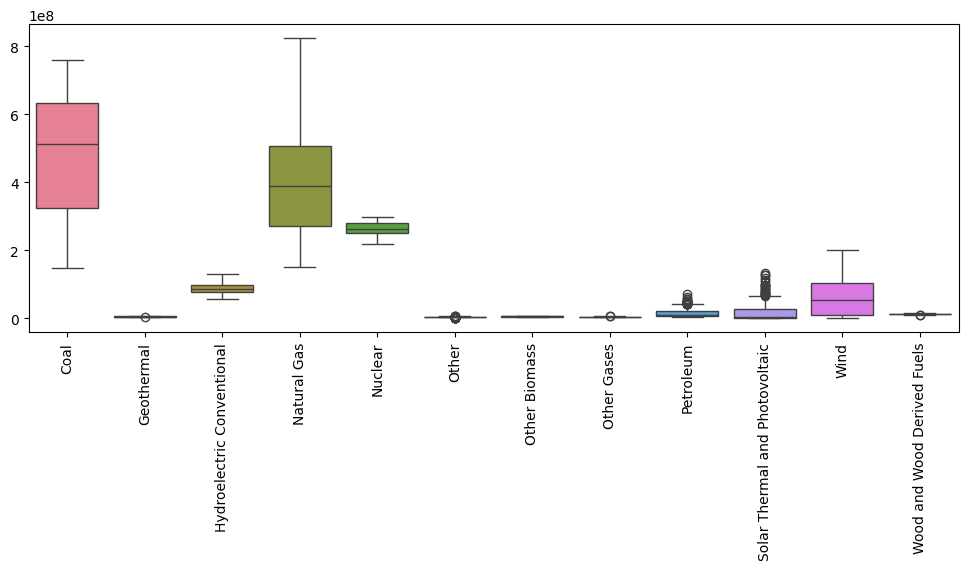

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize = (12,4))
ax = sns.boxplot(SERIES, ax = ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)